Using CUDA (NVIDIA).
Running prediction...


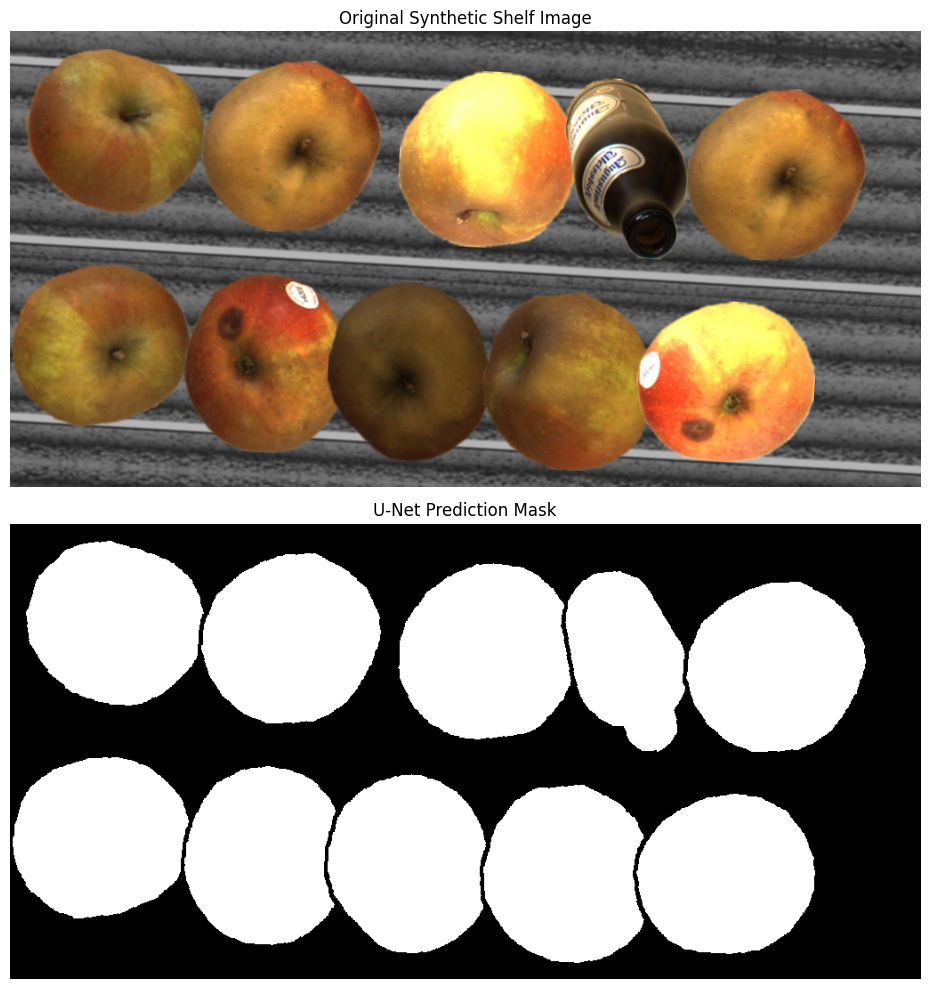

In [1]:
import torch
import cv2
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from unet import UNet
import deep_watershed_transform_network as dwt_network
import direction_network_model as dn_model

# Configuration
# TEST_IMAGE_NAME = "planogram.png"

TEST_IMAGE_NAME = "Apple Red Boskoop Shelf.png"

# TEST_IMAGE_NAME = "realogram_correct.png"
# TEST_IMAGE_NAME = "realogram_incorrect.png"


# TEST_IMAGE_NAME = "stress_test_shelf_1.png"


MODEL_UNET_WEIGHTS = "best_unet_model.pth"
MODEL_DN_WEIGHTS = "best_dn_model.pth"
MODEL_WTN_WEIGHTS = "best_wtn_model.pth"
MODEL_RESNET_WEIGHTS = "best_resnet_model.pth"
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Success: Using Apple Metal (MPS) acceleration.")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA (NVIDIA).")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU (Warning: This will be slower).")

# Load Model
unet_model = UNet(in_channels=3, num_classes=2).to(DEVICE)
unet_model.load_state_dict(torch.load(MODEL_UNET_WEIGHTS, map_location=DEVICE))
unet_model.eval()

# Load and Preprocess Image
img_bgr = cv2.imread(TEST_IMAGE_NAME)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Resize
img_resized = cv2.resize(img_rgb, (1024, 512))

# Match conversion logic
input_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(DEVICE)

# Run Inference
print("Running prediction...")
with torch.no_grad():
    output = unet_model(input_tensor)
    unet_pred_map = torch.argmax(output, dim=1).squeeze().cpu().numpy().astype(np.uint8)

# Visualize Results
fig, ax = plt.subplots(2, 1, figsize=(16, 10))
ax[0].imshow(img_resized)
ax[0].set_title("Original Synthetic Shelf Image")
ax[0].axis('off')

ax[1].imshow(unet_pred_map * 255, cmap='gray')
ax[1].set_title("U-Net Prediction Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

Running DWT prediction...


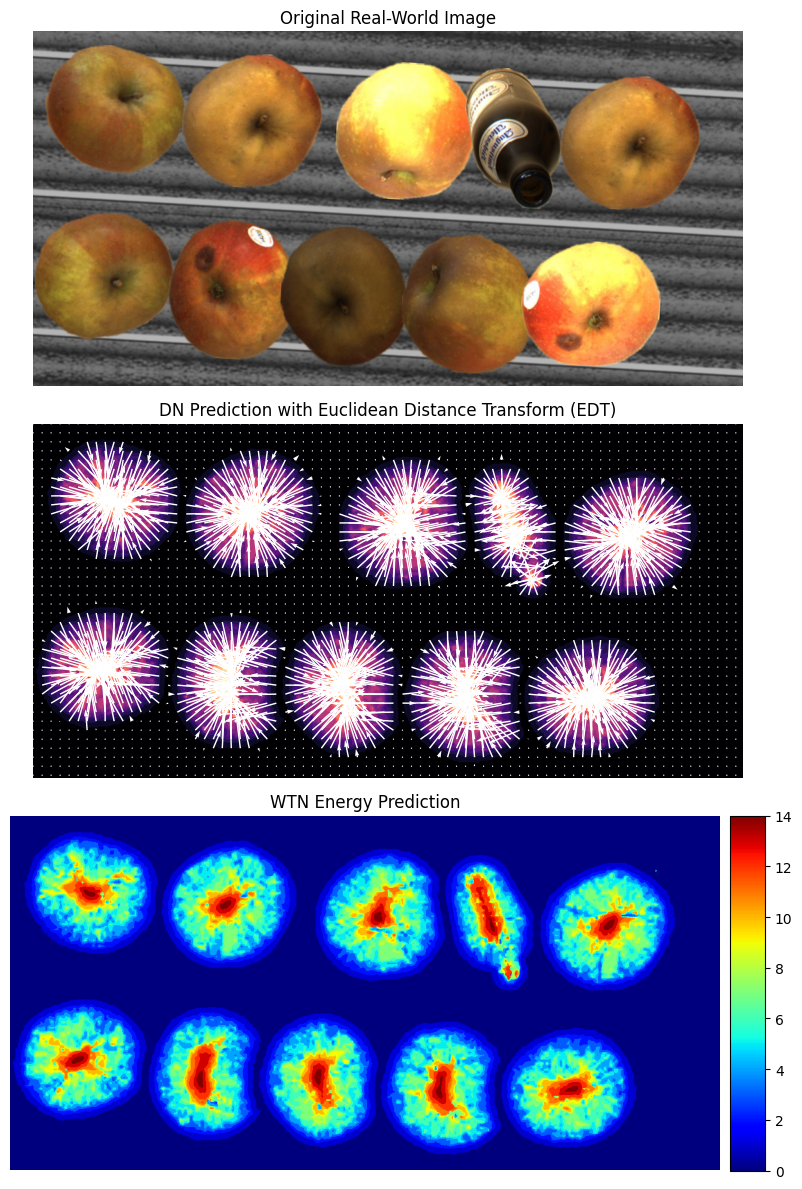

In [2]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

img_float = img_resized.astype(np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_norm = (img_float - mean) / std

# Prepare the mask from U-Net (ensure it's 0.0 or 1.0)
mask_float = unet_pred_map.astype(np.float32)
mask_expanded = np.expand_dims(mask_float, axis=2) # Shape: (H, W, 1)

# Multiply RGB by mask, then concatenate the mask as the 4th channel
rgb_gated = img_norm * mask_expanded
input_np = np.concatenate([rgb_gated, mask_expanded], axis=2) # Shape: (H, W, 4)

# Convert to Tensor [Batch, Channel, Height, Width]
dn_input = torch.from_numpy(input_np).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)

# Direction Network Model
dn_model = dn_model.DirectionNetwork().to(DEVICE)
dn_model.load_state_dict(torch.load(MODEL_DN_WEIGHTS, map_location=DEVICE))
dn_model.eval()

# Deep Watershed Transform Model
wtn_model = dwt_network.WatershedTransformNetwork().to(DEVICE)
wtn_model.load_state_dict(torch.load(MODEL_WTN_WEIGHTS, map_location=DEVICE))
wtn_model.eval()

# Run Inference
print("Running DWT prediction...")
with torch.no_grad():
    direction_pred = dn_model(dn_input)
    energy_logits = wtn_model(direction_pred)
    wtn_pred_map = torch.argmax(energy_logits, dim=1).squeeze().cpu().numpy().astype(np.uint8)

# Visualization (15 x 17 = 255)
# Scale max predicted value to 255 for visibility
normalized_map = (wtn_pred_map * 17).astype(np.uint8)


# Visualize Results
fig, ax = plt.subplots(3, 1, figsize=(18, 12))
ax[0].imshow(img_resized)
ax[0].set_title("Original Real-World Image")
ax[0].axis('off')

dir_np = direction_pred.squeeze().cpu().numpy()
u_x = dir_np[0]
u_y = dir_np[1]
h, w = wtn_pred_map.shape
x, y = np.meshgrid(np.arange(w), np.arange(h))
step = 13
sub_x = x[::step, ::step]
sub_y = y[::step, ::step]
sub_u = u_x[::step, ::step]
sub_v = u_y[::step, ::step]
ax[1].imshow(wtn_pred_map, cmap='magma')
ax[1].quiver(sub_x, sub_y, sub_u, -sub_v, color='white', scale=20, width=0.002)
ax[1].set_title("DN Prediction with Euclidean Distance Transform (EDT)")
ax[1].axis('off')

im_en = ax[2].imshow(wtn_pred_map, cmap='jet')
ax[2].set_title("WTN Energy Prediction")
ax[2].axis('off')



divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_en, cax=cax)

# cbar = fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
# cbar.set_label('Energy Level (Scaled 0-255)', rotation=270, labelpad=15)


plt.tight_layout()
plt.show()

In [3]:
import torchvision.transforms as T
from PIL import Image
import os
import cv2

def pad_to_square(image):
    w, h = image.size
    max_wh = max(w, h)
    hp = (max_wh - w) // 2
    vp = (max_wh - h) // 2
    # padding is (left, top, right, bottom)
    padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
    return T.functional.pad(image, padding, 0, 'constant')

SAVE_DIR = "dectected_crops"
os.makedirs(SAVE_DIR, exist_ok=True)


# Binarize the energy map to find all foreground objects
# (Assuming 0 is background, > 0 is foreground)
binary_mask = (wtn_pred_map > 0).astype(np.uint8) * 255

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask)

# ResNet-18 specific preprocessing
geom_transform = T.Compose([
    T.Lambda(pad_to_square),
    T.Resize((448, 448))
])

# Tensor (Convert & Normalize)
tensor_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

object_crops = []
valid_boxes = []

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    if area < 200: continue

    # Crop and apply Geometric transform ONCE
    crop = img_resized[y:y+h, x:x+w]
    crop_pil = Image.fromarray(crop)
    padded_view_pil = geom_transform(crop_pil) # <--- Logic runs once here

    # Save the visual version (RGB to BGR for cv2)
    padded_view_cv2 = cv2.cvtColor(np.array(padded_view_pil), cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(SAVE_DIR, f"crop_{i:03d}.png"), padded_view_cv2)

    # Finalize for ResNet (Convert to Tensor)
    input_tensor = tensor_transform(padded_view_pil).unsqueeze(0).to(DEVICE)
    object_crops.append(input_tensor)

    valid_boxes.append((x,y,w,h))

print(f"Isolated {len(object_crops)} items for ResNet processing.")

Isolated 10 items for ResNet processing.


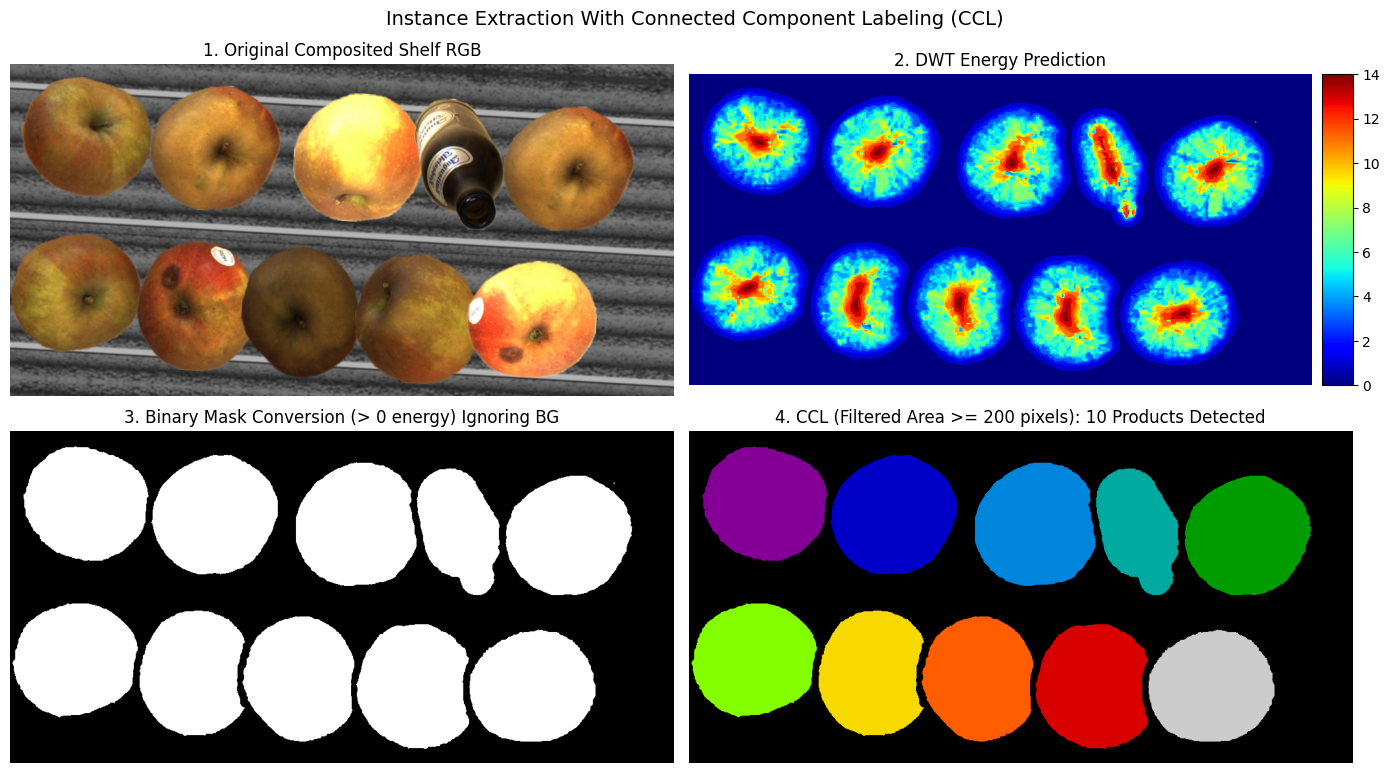

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Prepare data binary conversion
binary_mask = (wtn_pred_map > 0).astype(np.uint8) * 255
# Connected Components Labeling
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask)

# --- FILTER LOGIC: Remove < 200 pixels ---
filtered_labels = labels.copy()
valid_count = 0

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area < 200:
        filtered_labels[labels == i] = 0  # Set noise to background (0)
    else:
        valid_count += 1

# Setup 2x2 Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original Image
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title("1. Original Composited Shelf RGB")

# Energy Map
# cmap = plt.cm.jet.with_extremes(bad='black')
# masked_map = np.ma.masked_where(wtn_pred_map <= 0, wtn_pred_map)
im_en = axes[0, 1].imshow(wtn_pred_map, cmap='jet')
axes[0, 1].set_title("2. DWT Energy Prediction")

divider = make_axes_locatable(axes[0, 1])
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_en, cax=cax)

# Binary Conversion
axes[1, 0].imshow(binary_mask, cmap='gray')
axes[1, 0].set_title("3. Binary Mask Conversion (> 0 energy) Ignoring BG")

# CC Labels
im_cc = axes[1, 1].imshow(filtered_labels, cmap='nipy_spectral')
axes[1, 1].set_title(f"4. CCL (Filtered Area >= 200 pixels): {valid_count} Products Detected")

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle("Instance Extraction With Connected Component Labeling (CCL)", fontsize=14)
plt.tight_layout()
plt.savefig("my_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
class_mapping = {
'Adelholzener Alpenquelle Classic (Sparkling)': 0,
'Adelholzener Alpenquelle Naturell (Still)': 1,
'Adelholzener Classic Bio Apfelschorle': 2,
'Adelholzener Classic Naturell': 3,
'Adelholzener Gourmet Mineralwasser': 4,
'Apple Braeburn Bundle': 5,
'Apple Golden Delicious': 6,
'Apple Granny Smith': 7,
'Apple Red Boskoop': 8,
'Augustiner Lagerbraeu Hell': 9,
'Augustiner Weissbier': 10,
'Avocado': 11,
'Banana Bundle': 12,
'Banana Single': 13,
'Cafe Wunderbar Espresso': 14,
'Caona Cocoa': 15,
'Carrot': 16,
'Clementine': 17,
'Clementine Single': 18,
'Coca Cola': 19,
'Coca Cola Light': 20,
'Cocoba Cocoa': 21,
'Corn Salad': 22,
'Corny Nussvoll': 23,
'Corny Nussvoll Single': 24,
'Corny Schoko Banane': 25,
'Corny Schoko Banane Single': 26,
'Cucumber': 27,
'Douwe Egberts Professional Ground Coffee': 28,
'Dr Oetker Vitalis Knuspermuesli Klassisch': 29,
'Ethiquable Gruener Tee Ceylon': 30,
'Franken Tafelreiniger': 31,
'Gepa Bio Caffe Crema': 32,
'Gepa Bio Und Fair Fencheltee': 33,
'Gepa Bio Und Fair Kamillentee': 34,
'Gepa Bio Und Fair Kraeuterteemischung': 35,
'Gepa Bio Und Fair Pfefferminztee': 36,
'Gepa Bio Und Fair Rooibostee': 37,
'Gepa Italienischer Bio Espresso': 38,
'Grapes Green Sugraone Seedless': 39,
'Grapes Sweet Celebration Seedless': 40,
'Kilimanjaro Tea Earl Grey': 41,
'Kiwi': 42,
'Koelln Muesli Fruechte': 43,
'Koelln Muesli Schoko': 44,
'Lettuce': 45,
'Orange Single': 46,
'Oranges': 47,
'Pasta Reggia Elicoidali': 48,
'Pasta Reggia Fusilli': 49,
'Pasta Reggia Spaghetti': 50,
'Pear': 51,
'Pelikan Tintenpatrone Canon': 52,
'Rocket': 53,
'Roma Vine Tomatoes': 54,
'Salad Iceberg': 55,
'Suntory Gokuri Lemonade': 56,
'Tegernseer Hell': 57,
'Vine Tomatoes': 58,
'Zucchini': 59
}


--- Classifying 10 detected items ---
[1] Apple Red Boskoop (100.00%)
[2] Apple Red Boskoop (100.00%)
[3] Apple Red Boskoop (100.00%)
[4] Augustiner Weissbier (100.00%)
[5] Apple Red Boskoop (100.00%)
[6] Apple Red Boskoop (100.00%)
[7] Apple Red Boskoop (100.00%)
[8] Apple Red Boskoop (100.00%)
[9] Apple Red Boskoop (100.00%)
[10] Apple Red Boskoop (100.00%)


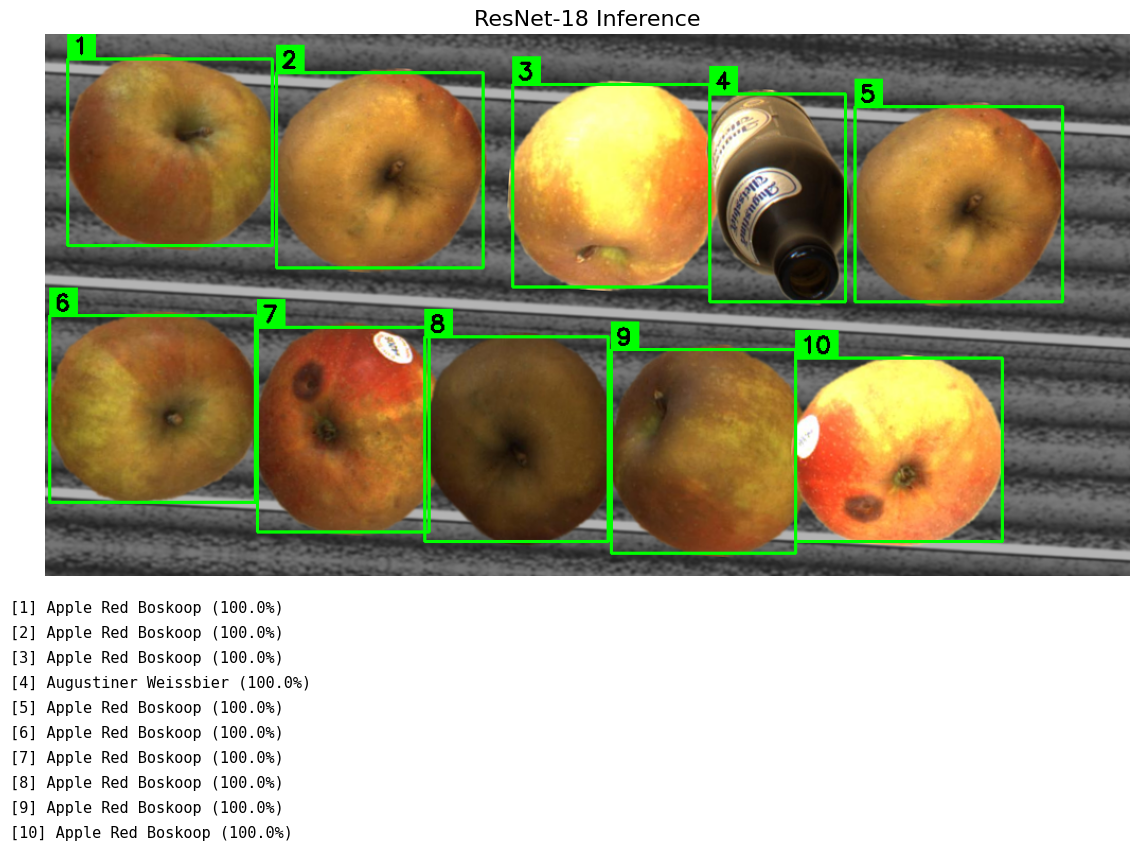

In [6]:
from torchvision import models

class_names = sorted(class_mapping, key=class_mapping.get)

# --- LOAD TRAINED MODEL ---
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load("best_resnet_model.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

print(f"\n--- Classifying {len(object_crops)} detected items ---")

final_detections = []
with torch.no_grad():
    for i, input_tensor in enumerate(object_crops):
        # Forward pass
        output = model(input_tensor)

        # Get probability and index
        prob = torch.nn.functional.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)

        label = class_names[pred.item()]
        confidence = conf.item()

        # Store results with coordinates
        x, y, w, h = valid_boxes[i]
        final_detections.append({
            "label": label,
            "conf": confidence,
            "bbox": (x, y, w, h)
        })

        print(f"[{i+1}] {label} ({confidence:.2%})")

display_img = img_rgb.copy()
# --- VISUALISE RESULTS ---
legend_items = []
for i, det in enumerate(final_detections):
    x, y, w, h = det["bbox"]
    item_id = str(i + 1)

    # Draw the bounding box and the solid background ID tag
    cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (text_w, text_h), _ = cv2.getTextSize(item_id, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(display_img, (x, y - text_h - 10), (x + text_w + 10, y), (0, 255, 0), -1)
    cv2.putText(display_img, item_id, (x + 5, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Save the string for the Matplotlib legend instead of printing it
    legend_items.append(f"[{item_id}] {det['label']} ({det['conf']:.1%})")

# Setup Matplotlib figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(display_img)
ax.axis('off')
ax.set_title(f"ResNet-18 Inference", fontsize=16)

# Draw the legend underneath the image in columns
MAX_ROWS_PER_COLUMN = 15

for idx, item_text in enumerate(legend_items):
    col = idx // MAX_ROWS_PER_COLUMN
    row = idx % MAX_ROWS_PER_COLUMN
    x_pos = 0.10 + (col * 0.30)
    y_pos = 0.20 - (row * 0.025)
    fig.text(x_pos, y_pos, item_text, fontsize=11, ha='left', va='top', family='monospace')


plt.show()

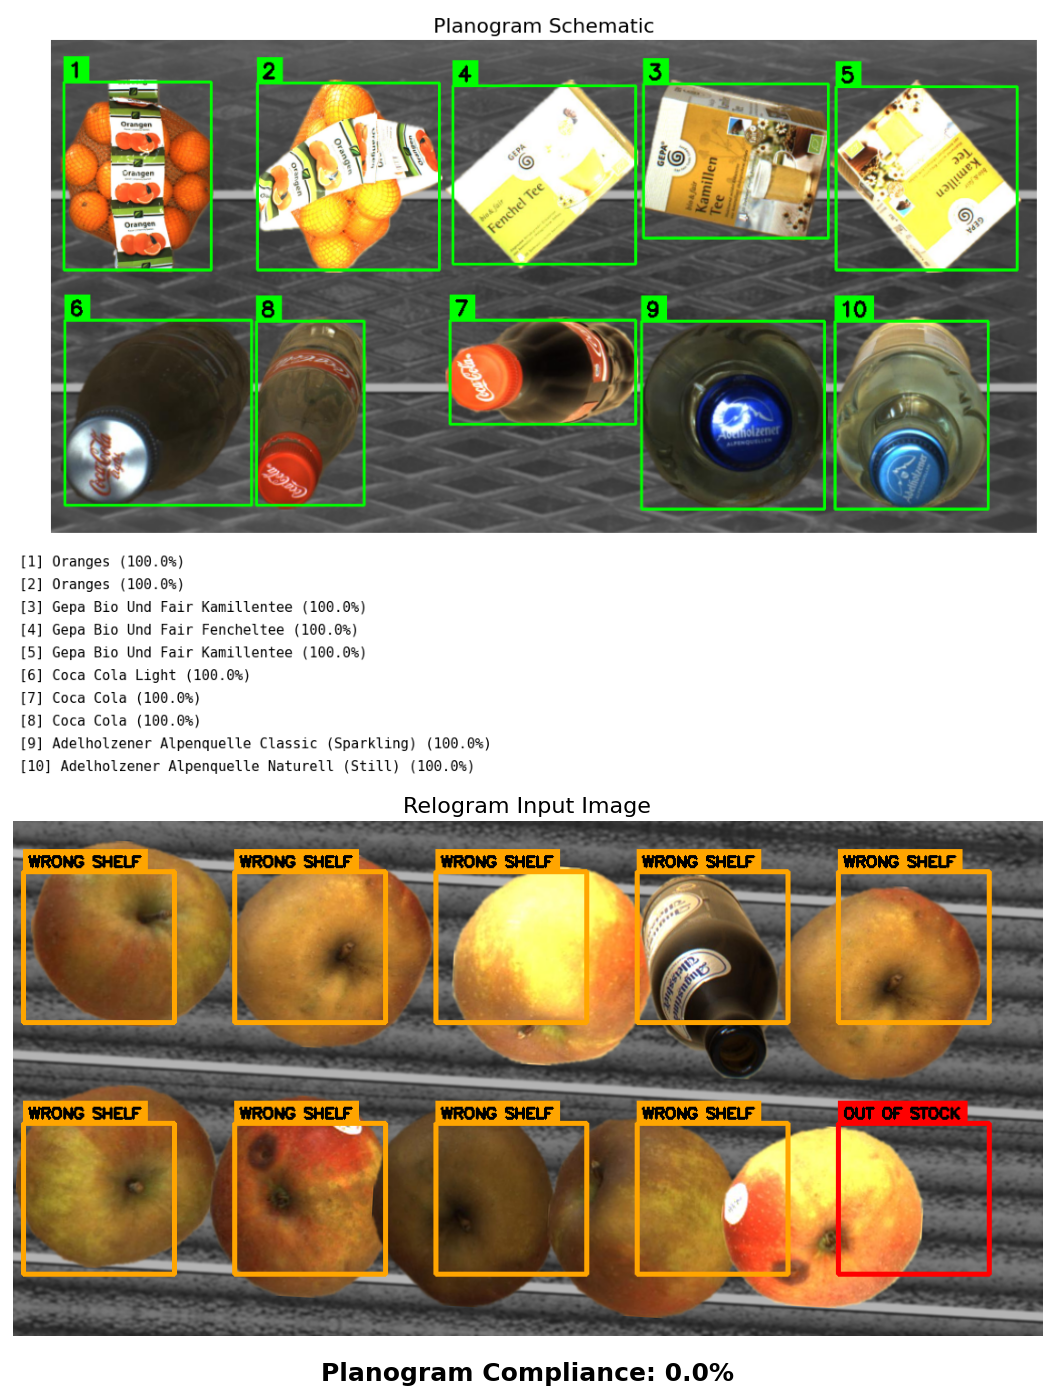

In [7]:
import cv2
import matplotlib.pyplot as plt

# Setup Planogram Data
monitored_products = [
    {"label": "Oranges", "rect": (10, 50, 150, 150)},
    {"label": "Oranges", "rect": (220, 50, 150, 150)},
    {"label": "Gepa Bio Und Fair Fencheltee", "rect": (420, 50, 150, 150)},
    {"label": "Gepa Bio Und Fair Kamillentee", "rect": (620, 50, 150, 150)},
    {"label": "Gepa Bio Und Fair Kamillentee", "rect": (820, 50, 150, 150)},

    {"label": "Coca Cola Light", "rect": (10, 300, 150, 150)},
    {"label": "Coca Cola", "rect": (220, 300, 150, 150)},
    {"label": "Coca Cola", "rect": (420, 300, 150, 150)},
    {"label": "Adelholzener Alpenquelle Classic (Sparkling)", "rect": (620, 300, 150, 150)},
    {"label": "Adelholzener Alpenquelle Naturell (Still)", "rect": (820, 300, 150, 150)},
]

planogram_product_names = list(set([item['label'] for item in monitored_products]))

# Prepare Drawing Canvas
display_img = img_rgb.copy()
correct_count = 0  # Counter for final percentage

# Process Each Slot
for item in monitored_products:
    target = item["label"]
    px, py, pw, ph = item["rect"]

    found_correct = False
    found_wrong_location = False
    found_wrong_shelf = False

    # Check detections against this specific box
    for det in final_detections:
        dx, dy, dw, dh = det["bbox"]
        center_x, center_y = dx + (dw // 2), dy + (dh // 2)

        if (px <= center_x <= px + pw) and (py <= center_y <= py + ph):
            if det['label'] == target:
                found_correct = True
                correct_count += 1 # Increment for compliance math
                break
            elif det['label'] in planogram_product_names:
                found_wrong_location = True
            else:
                found_wrong_shelf = True

    # --- COLOR & TEXT SELECTION ---
    if found_correct:
        color = (0, 255, 0)      # Green
        status_text = "CORRECT"
    elif found_wrong_location:
        color = (255, 255, 255)  # White
        status_text = "WRONG LOCATION"
    elif found_wrong_shelf:
        color = (255, 165, 0)    # Orange
        status_text = "WRONG SHELF"
    else:
        color = (255, 0, 0)      # Red
        status_text = "OUT OF STOCK"

    # Draw the Main Bounding Box (Border only)
    cv2.rectangle(display_img, (px, py), (px + pw, py + ph), color, 3)

    # Draw the Status Tag (Solid Box above the top-left)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(status_text, font, font_scale, thickness)

    cv2.rectangle(display_img,
                  (px, py - th - 10),
                  (px + tw + 10, py),
                  color, -1)

    # Draw the Status Text in Black
    cv2.putText(display_img, status_text, (px + 5, py - 5),
                font, font_scale, (0, 0, 0), thickness)

# Final Compliance Calculation
compliance_pct = (correct_count / len(monitored_products)) * 100
compliance_text = f"Planogram Compliance: {compliance_pct:.1f}%"

# Final Display
fig, (ax_planogram, ax_relogram) = plt.subplots(2,1, figsize=(16,14), gridspec_kw={'height_ratios':[1.5,1]})

planogram_img = cv2.imread("planogram_analyis.png", cv2.IMREAD_COLOR_RGB)
ax_planogram.imshow(planogram_img)
ax_planogram.axis('off')

ax_relogram.set_title("Relogram Input Image", fontsize=16)
ax_relogram.imshow(display_img)
ax_relogram.axis('off')

# Input compliance text below image
plt.text(0.5, -0.05, compliance_text,
         size=18,
         ha="center",
         va="top",
         transform=plt.gca().transAxes,
         fontweight='bold',
         color='black')

plt.savefig(f"{os.path.splitext(TEST_IMAGE_NAME)[0]}_inference.png", bbox_inches='tight', pad_inches=0.1)
plt.tight_layout()
plt.savefig("plano.png")
plt.show()

In [8]:
# # (x, y, w, h) for each status box
# monitored_products = [
#     {"label": "Oranges", "rect": (10, 50, 150, 150)},
#     {"label": "Oranges", "rect": (220, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Fencheltee", "rect": (420, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Kamillentee", "rect": (620, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Kamillentee", "rect": (820, 50, 150, 150)},
#
#     {"label": "Coca Cola Light", "rect": (10, 300, 150, 150)},
#     {"label": "Coca Cola", "rect": (220, 300, 150, 150)},
#     {"label": "Coca Cola", "rect": (420, 300, 150, 150)},
#     {"label": "Adelholzener Alpenquelle Classic (Sparkling)", "rect": (620, 300, 150, 150)},
#     {"label": "Adelholzener Alpenquelle Naturell (Still)", "rect": (820, 300, 150, 150)},
# ]
#
# display_img = img_rgb.copy()
#
# for item in monitored_products:
#     target = item["label"]
#     px, py, pw, ph = item["rect"]
#
#     found_correct = False
#     found_wrong = False
#
#     # Check detections against this specific box
#     for det in final_detections:
#         dx, dy, dw, dh = det["bbox"]
#         center_x, center_y = dx + (dw // 2), dy + (dh // 2)
#
#         if (px <= center_x <= px + pw) and (py <= center_y <= py + ph):
#             if det['label'] == target:
#                 found_correct = True
#                 break
#             else:
#                 found_wrong = True
#
#     # --- COLOR & TEXT SELECTION ---
#     if found_correct:
#         color = (0, 255, 0)      # Green
#         status_text = "CORRECT"
#     elif found_wrong:
#         color = (255, 165, 0)    # Orange
#         status_text = "INCORRECT"
#     else:
#         color = (255, 0, 0)      # Red
#         status_text = "MISSING"
#
#     # 1. Draw the Main Bounding Box (Border only)
#     cv2.rectangle(display_img, (px, py), (px + pw, py + ph), color, 3)
#
#     # 2. Draw the Status Tag (Solid Box above the top-left)
#     font = cv2.FONT_HERSHEY_SIMPLEX
#     font_scale = 0.5
#     thickness = 2
#
#     # Calculate text size to make the background box fit perfectly
#     (tw, th), baseline = cv2.getTextSize(status_text, font, font_scale, thickness)
#
#     # Draw solid background rectangle for the text
#     # Position: Just above px, py
#     cv2.rectangle(display_img,
#                   (px, py - th - 10),
#                   (px + tw + 10, py),
#                   color, -1)
#
#     # 3. Draw the Status Text in Black (0, 0, 0)
#     cv2.putText(display_img, status_text, (px + 5, py - 5),
#                 font, font_scale, (0, 0, 0), thickness)
#
# # --- Final Display ---
# plt.figure(figsize=(12, 10))
# plt.imshow(display_img)
# plt.axis('off')
# # plt.savefig(f"{os.path.splitext(TEST_IMAGE_NAME)[0]}_inference.png", bbox_inches='tight', pad_inches=0.1)
# plt.show()

In [9]:
# import cv2
# import matplotlib.pyplot as plt
#
# # Setup Planogram Data
# monitored_products = [
#     {"label": "Oranges", "rect": (10, 50, 150, 150)},
#     {"label": "Oranges", "rect": (220, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Fencheltee", "rect": (420, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Kamillentee", "rect": (620, 50, 150, 150)},
#     {"label": "Gepa Bio Und Fair Kamillentee", "rect": (820, 50, 150, 150)},
#
#     {"label": "Coca Cola Light", "rect": (10, 300, 150, 150)},
#     {"label": "Coca Cola", "rect": (220, 300, 150, 150)},
#     {"label": "Coca Cola", "rect": (420, 300, 150, 150)},
#     {"label": "Adelholzener Alpenquelle Classic (Sparkling)", "rect": (620, 300, 150, 150)},
#     {"label": "Adelholzener Alpenquelle Naturell (Still)", "rect": (820, 300, 150, 150)},
# ]
#
# planogram_product_names = list(set([item['label'] for item in monitored_products]))
#
# # Prepare Drawing Canvas
# display_img = img_rgb.copy()
# correct_count = 0  # Counter for final percentage
#
# # Process Each Slot
# for item in monitored_products:
#     target = item["label"]
#     px, py, pw, ph = item["rect"]
#
#     found_correct = False
#     found_wrong_location = False
#     found_wrong_shelf = False
#
#     # Check detections against this specific box
#     for det in final_detections:
#         dx, dy, dw, dh = det["bbox"]
#         center_x, center_y = dx + (dw // 2), dy + (dh // 2)
#
#         if (px <= center_x <= px + pw) and (py <= center_y <= py + ph):
#             if det['label'] == target:
#                 found_correct = True
#                 correct_count += 1 # Increment for compliance math
#                 break
#             elif det['label'] in planogram_product_names:
#                 found_wrong_location = True
#             else:
#                 found_wrong_shelf = True
#
#     # --- COLOR & TEXT SELECTION ---
#     if found_correct:
#         color = (0, 255, 0)      # Green
#         status_text = "CORRECT"
#     elif found_wrong_location:
#         color = (255, 255, 255)  # White
#         status_text = "WRONG LOCATION"
#     elif found_wrong_shelf:
#         color = (255, 165, 0)    # Orange
#         status_text = "WRONG SHELF"
#     else:
#         color = (255, 0, 0)      # Red
#         status_text = "OUT OF STOCK"
#
#     # Draw the Main Bounding Box (Border only)
#     cv2.rectangle(display_img, (px, py), (px + pw, py + ph), color, 3)
#
#     # Draw the Status Tag (Solid Box above the top-left)
#     font = cv2.FONT_HERSHEY_SIMPLEX
#     font_scale = 0.5
#     thickness = 2
#     (tw, th), baseline = cv2.getTextSize(status_text, font, font_scale, thickness)
#
#     cv2.rectangle(display_img,
#                   (px, py - th - 10),
#                   (px + tw + 10, py),
#                   color, -1)
#
#     # Draw the Status Text in Black
#     cv2.putText(display_img, status_text, (px + 5, py - 5),
#                 font, font_scale, (0, 0, 0), thickness)
#
# # Final Compliance Calculation
# compliance_pct = (correct_count / len(monitored_products)) * 100
# compliance_text = f"Planogram Compliance: {compliance_pct:.1f}%"
#
# # Final Display
# plt.figure(figsize=(12, 10))
# plt.imshow(display_img)
# plt.axis('off')
#
# # Input compliance text below image
# plt.text(0.5, -0.05, compliance_text,
#          size=18,
#          ha="center",
#          va="top",
#          transform=plt.gca().transAxes,
#          fontweight='bold',
#          color='black')
#
# plt.savefig(f"{os.path.splitext(TEST_IMAGE_NAME)[0]}_inference.png", bbox_inches='tight', pad_inches=0.1)
# plt.show()